In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

processed_data_path = (
    project_root
    / "data"
    / "processed"
    / "heart_disease_clean.csv"
)

if not processed_data_path.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found: {processed_data_path}"
    )

df = pd.read_csv(processed_data_path)

print("Dataset shape:", df.shape)
print("Total missing values:", int(df.isna().sum().sum()))

df.head()

Dataset shape: (4238, 16)
Total missing values: 645


,gender,age,education,current_smoker,cigarettes_per_day,bp_meds,prevalent_stroke,prevalent_hypertension,diabetes,total_cholesterol,systolic_bp,diastolic_bp,bmi,heart_rate,glucose,heart_disease
0,male,39,postgraduate,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,female,46,primary_school,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,male,48,uneducated,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,female,61,graduate,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,female,46,graduate,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


,Status,Count,Percentage
0,No Heart Disease,3594,84.8
1,Heart Disease,644,15.2


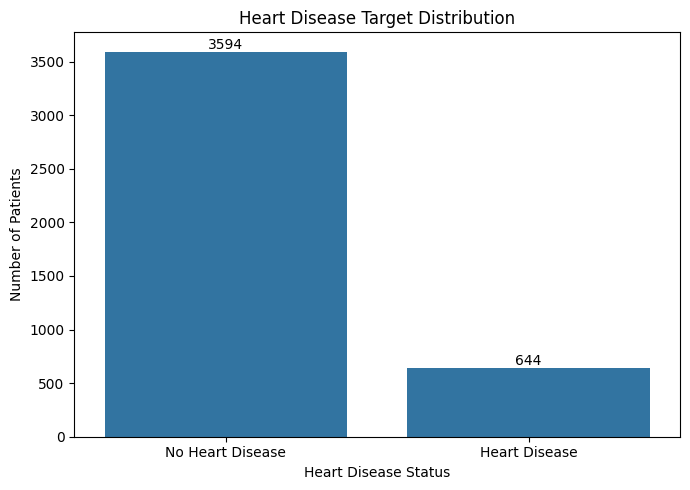

In [2]:
target_labels = {
    0: "No Heart Disease",
    1: "Heart Disease"
}

target_counts = (
    df["heart_disease"]
    .value_counts()
    .sort_index()
)

target_percentages = (
    target_counts / len(df) * 100
).round(2)

target_summary = pd.DataFrame({
    "Status": [
        target_labels[value]
        for value in target_counts.index
    ],
    "Count": target_counts.values,
    "Percentage": target_percentages.values
})

display(target_summary)

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="heart_disease",
    order=[0, 1]
)

ax.set_title("Heart Disease Target Distribution")
ax.set_xlabel("Heart Disease Status")
ax.set_ylabel("Number of Patients")
ax.set_xticks([0, 1])
ax.set_xticklabels([
    "No Heart Disease",
    "Heart Disease"
])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

,Feature,Missing Values,Mean,Median,Skewness
0,age,0,49.58,49.0,0.23
1,cigarettes_per_day,29,9.00,0.0,1.25
2,total_cholesterol,50,236.72,234.0,0.87
3,systolic_bp,0,132.35,128.0,1.15
4,diastolic_bp,0,82.89,82.0,0.71
5,bmi,19,25.80,25.4,0.98
6,heart_rate,1,75.88,75.0,0.64
7,glucose,388,81.97,78.0,6.21


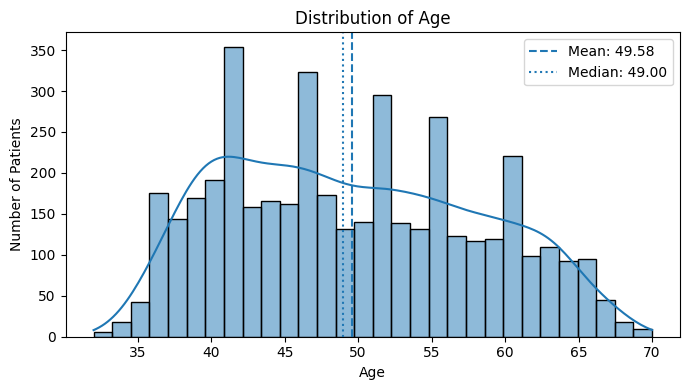

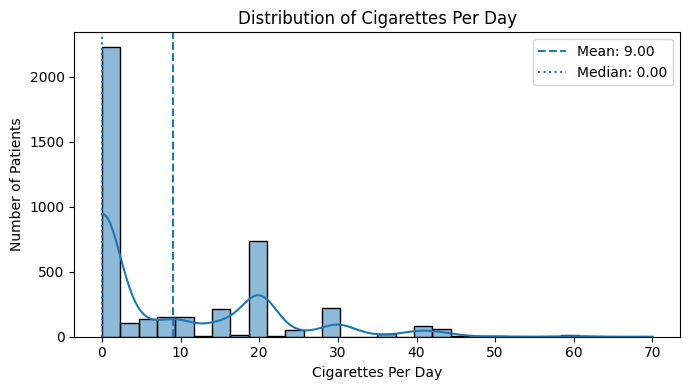

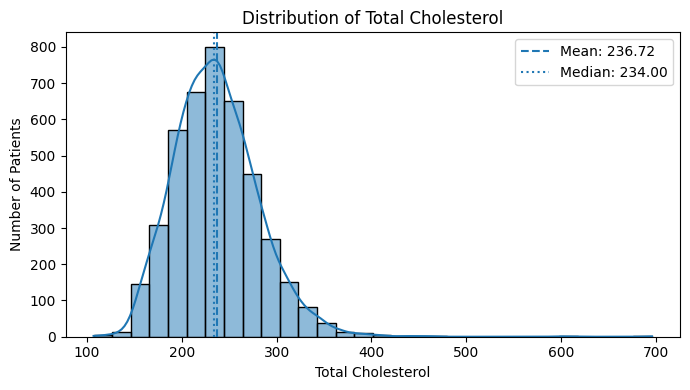

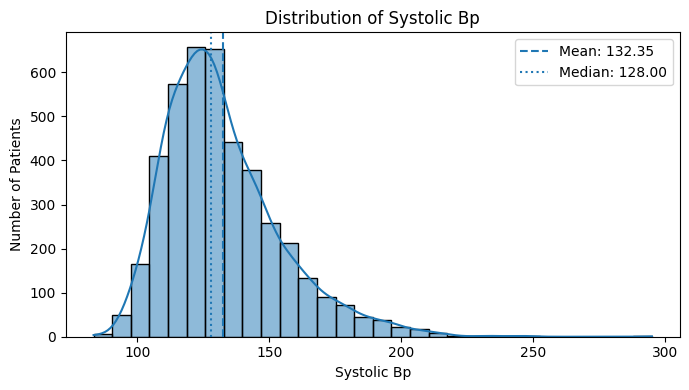

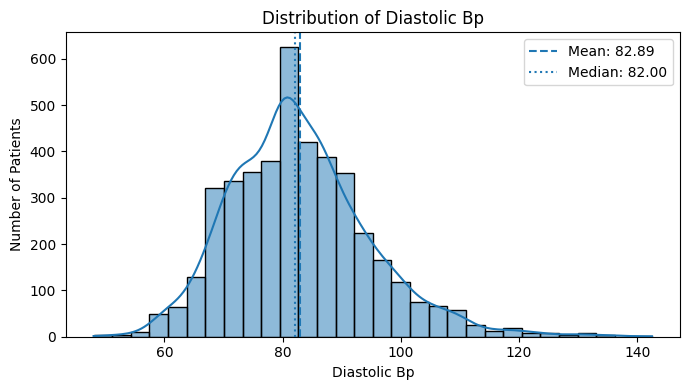

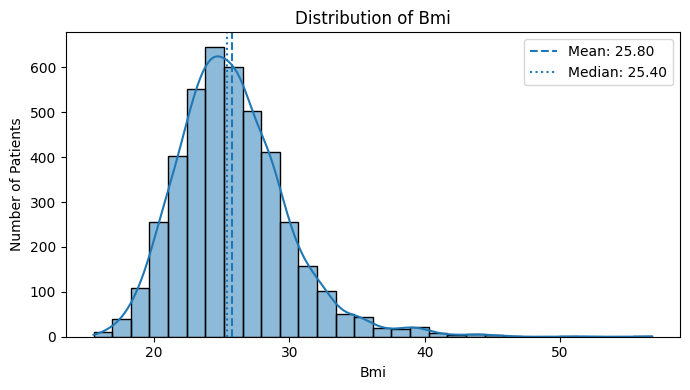

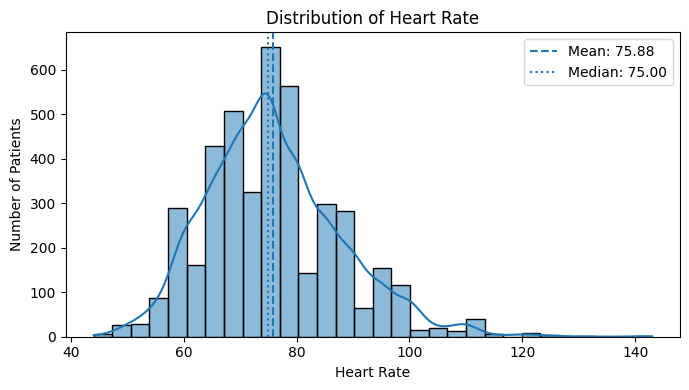

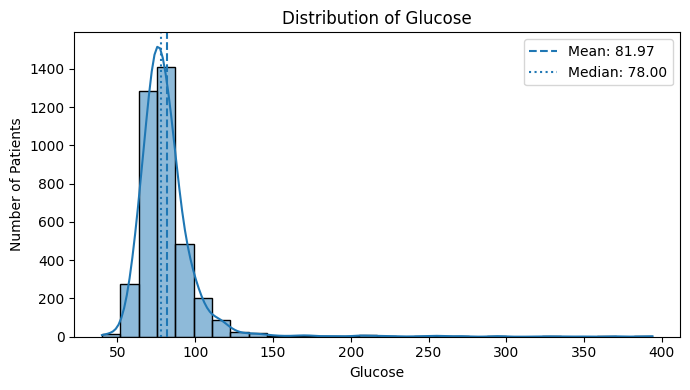

In [3]:
continuous_columns = [
    "age",
    "cigarettes_per_day",
    "total_cholesterol",
    "systolic_bp",
    "diastolic_bp",
    "bmi",
    "heart_rate",
    "glucose"
]

distribution_summary = pd.DataFrame({
    "Feature": continuous_columns,
    "Missing Values": [
        int(df[column].isna().sum())
        for column in continuous_columns
    ],
    "Mean": [
        round(df[column].mean(), 2)
        for column in continuous_columns
    ],
    "Median": [
        round(df[column].median(), 2)
        for column in continuous_columns
    ],
    "Skewness": [
        round(df[column].skew(), 2)
        for column in continuous_columns
    ]
})

display(distribution_summary)

for column in continuous_columns:
    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True
    )

    plt.axvline(
        df[column].mean(),
        linestyle="--",
        label=f"Mean: {df[column].mean():.2f}"
    )

    plt.axvline(
        df[column].median(),
        linestyle=":",
        label=f"Median: {df[column].median():.2f}"
    )

    plt.title(
        f"Distribution of {column.replace('_', ' ').title()}"
    )
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel("Number of Patients")
    plt.legend()
    plt.tight_layout()
    plt.show()

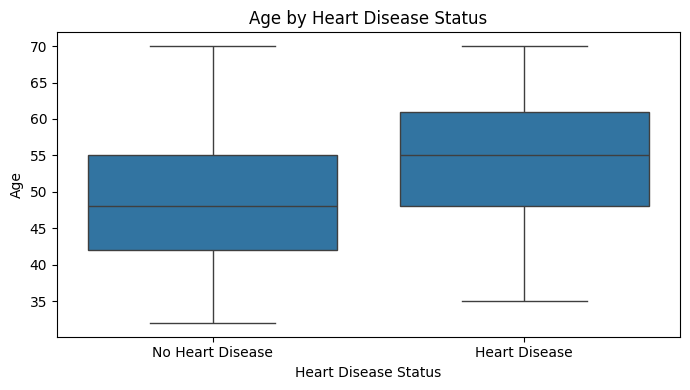

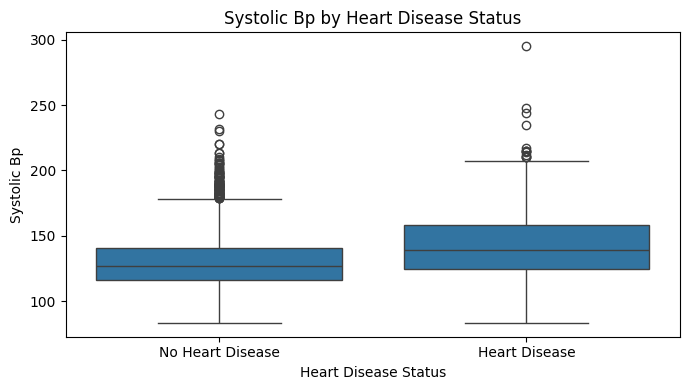

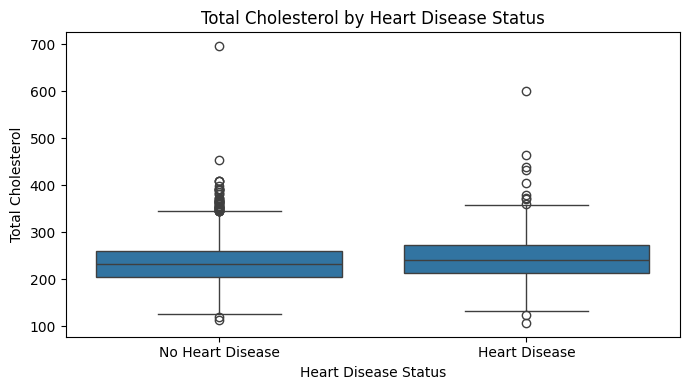

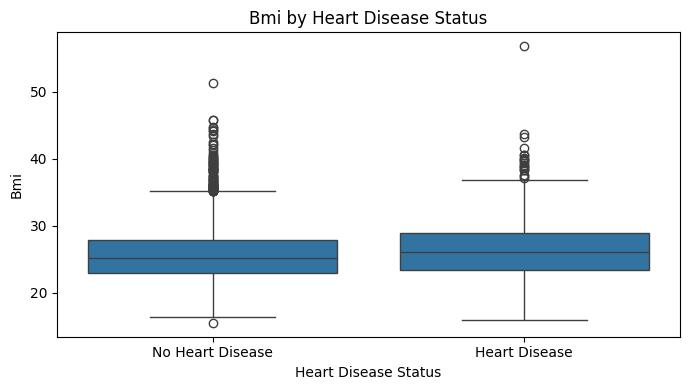

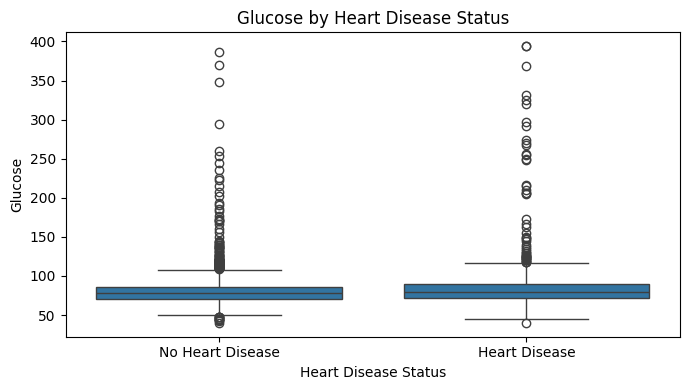

In [4]:
comparison_columns = [
    "age",
    "systolic_bp",
    "total_cholesterol",
    "bmi",
    "glucose"
]

for column in comparison_columns:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x="heart_disease",
        y=column
    )

    plt.title(
        f"{column.replace('_', ' ').title()} by Heart Disease Status"
    )
    plt.xlabel("Heart Disease Status")
    plt.ylabel(column.replace("_", " ").title())

    plt.xticks(
        ticks=[0, 1],
        labels=["No Heart Disease", "Heart Disease"]
    )

    plt.tight_layout()
    plt.show()

,gender,total_patients,heart_disease_cases,heart_disease_rate
0,female,2419,301,12.44
1,male,1819,343,18.86


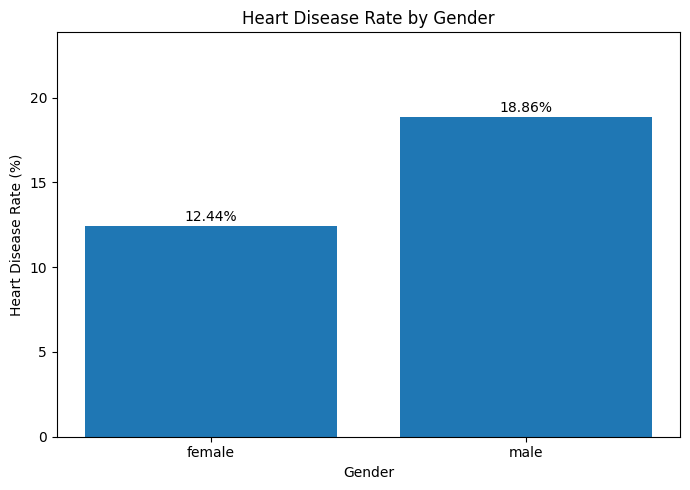

In [5]:
gender_analysis = (
    df.groupby("gender", dropna=False)["heart_disease"]
    .agg(
        total_patients="count",
        heart_disease_cases="sum"
    )
    .reset_index()
)

gender_analysis["heart_disease_rate"] = (
    gender_analysis["heart_disease_cases"]
    / gender_analysis["total_patients"]
    * 100
).round(2)

display(gender_analysis)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    gender_analysis["gender"],
    gender_analysis["heart_disease_rate"]
)

plt.title("Heart Disease Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Heart Disease Rate (%)")

plt.ylim(
    0,
    gender_analysis["heart_disease_rate"].max() + 5
)

for bar, rate in zip(
    bars,
    gender_analysis["heart_disease_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{rate:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


Heart disease analysis for Current Smoker:


,Status,total_patients,heart_disease_cases,heart_disease_rate
0,No,2144,311,14.51
1,Yes,2094,333,15.90


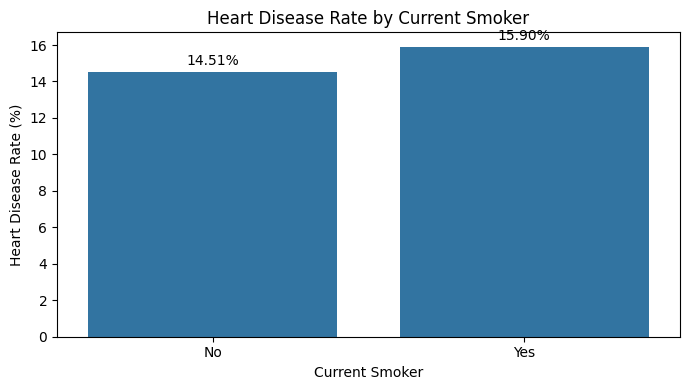


Heart disease analysis for Bp Meds:


,Status,total_patients,heart_disease_cases,heart_disease_rate
0,No,4061,592,14.58
1,Yes,124,41,33.06
2,Missing,53,11,20.75


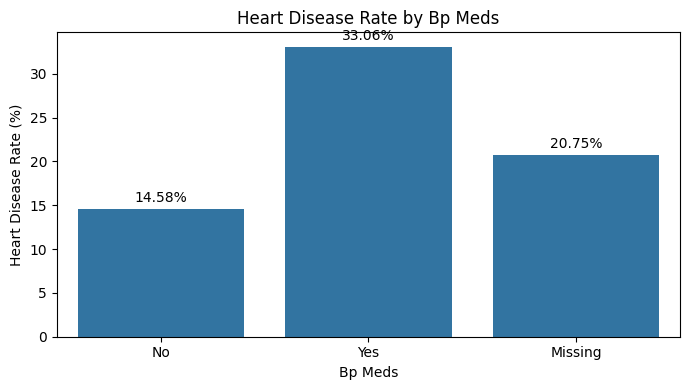


Heart disease analysis for Prevalent Stroke:


,Status,total_patients,heart_disease_cases,heart_disease_rate
0,No,4213,633,15.02
1,Yes,25,11,44.00


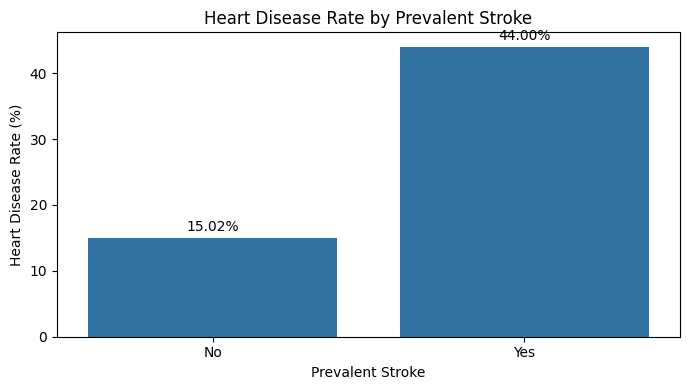


Heart disease analysis for Prevalent Hypertension:


,Status,total_patients,heart_disease_cases,heart_disease_rate
0,No,2922,319,10.92
1,Yes,1316,325,24.70


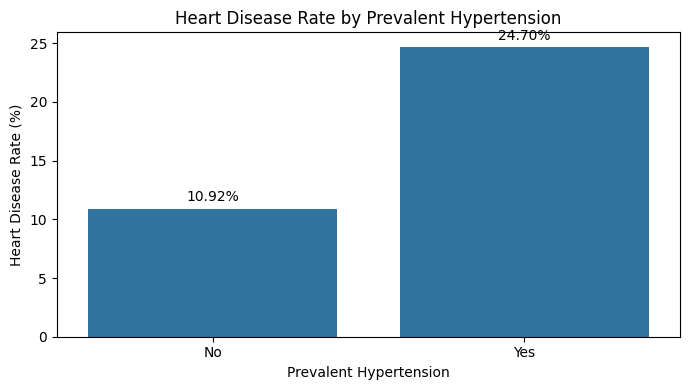


Heart disease analysis for Diabetes:


,Status,total_patients,heart_disease_cases,heart_disease_rate
0,No,4129,604,14.63
1,Yes,109,40,36.70


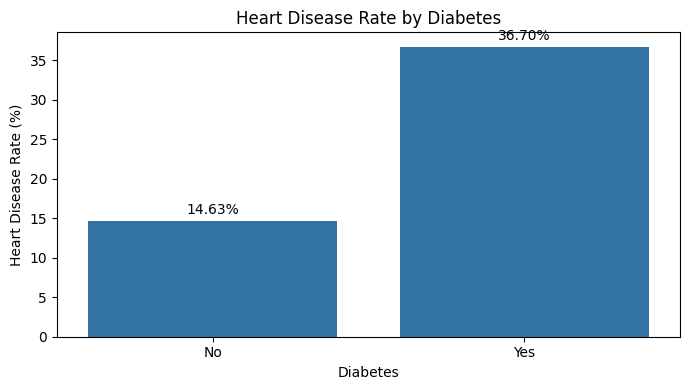

,Feature,Status,total_patients,heart_disease_cases,heart_disease_rate
0,current_smoker,No,2144,311,14.51
1,current_smoker,Yes,2094,333,15.90
2,bp_meds,No,4061,592,14.58
3,bp_meds,Yes,124,41,33.06
4,bp_meds,Missing,53,11,20.75
5,prevalent_stroke,No,4213,633,15.02
6,prevalent_stroke,Yes,25,11,44.00
7,prevalent_hypertension,No,2922,319,10.92
8,prevalent_hypertension,Yes,1316,325,24.70
9,diabetes,No,4129,604,14.63


In [6]:
binary_columns = [
    "current_smoker",
    "bp_meds",
    "prevalent_stroke",
    "prevalent_hypertension",
    "diabetes"
]

binary_analysis_results = []

for column in binary_columns:
    analysis = (
        df.groupby(column, dropna=False)["heart_disease"]
        .agg(
            total_patients="count",
            heart_disease_cases="sum"
        )
        .reset_index()
    )

    analysis["Status"] = (
        analysis[column]
        .map({
            0: "No",
            1: "Yes"
        })
        .fillna("Missing")
    )

    analysis["heart_disease_rate"] = (
        analysis["heart_disease_cases"]
        / analysis["total_patients"]
        * 100
    ).round(2)

    analysis["Feature"] = column

    binary_analysis_results.append(
        analysis[
            [
                "Feature",
                "Status",
                "total_patients",
                "heart_disease_cases",
                "heart_disease_rate"
            ]
        ]
    )

    print(
        f"\nHeart disease analysis for "
        f"{column.replace('_', ' ').title()}:"
    )

    display(
        analysis[
            [
                "Status",
                "total_patients",
                "heart_disease_cases",
                "heart_disease_rate"
            ]
        ]
    )

    plt.figure(figsize=(7, 4))

    ax = sns.barplot(
        data=analysis,
        x="Status",
        y="heart_disease_rate",
        order=[
            status
            for status in ["No", "Yes", "Missing"]
            if status in analysis["Status"].values
        ]
    )

    ax.set_title(
        f"Heart Disease Rate by "
        f"{column.replace('_', ' ').title()}"
    )
    ax.set_xlabel(column.replace("_", " ").title())
    ax.set_ylabel("Heart Disease Rate (%)")

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f%%",
            padding=3
        )

    plt.tight_layout()
    plt.show()

binary_analysis_summary = pd.concat(
    binary_analysis_results,
    ignore_index=True
)

display(binary_analysis_summary)

,education_group,total_patients,heart_disease_cases,heart_disease_rate
0,uneducated,1720,323,18.78
1,primary_school,1253,147,11.73
2,graduate,687,88,12.81
3,postgraduate,473,70,14.80
4,missing,105,16,15.24


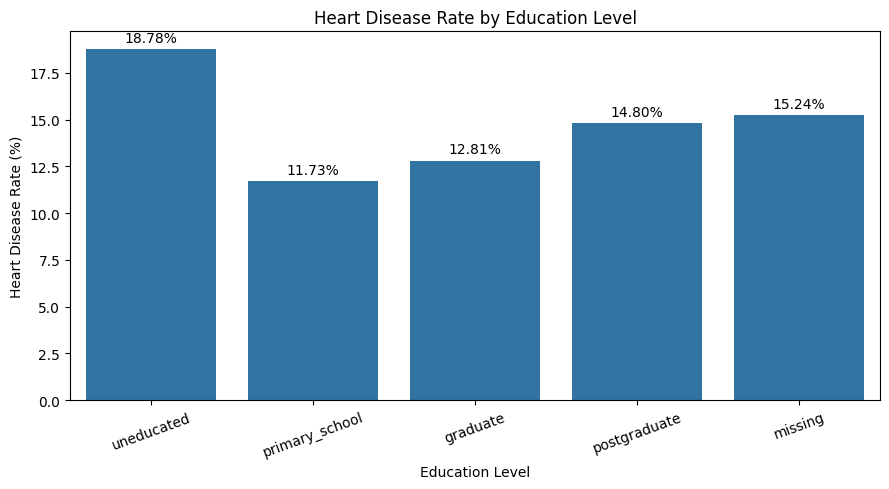

In [7]:
education_analysis_df = df[
    ["education", "heart_disease"]
].copy()

education_analysis_df["education_group"] = (
    education_analysis_df["education"]
    .fillna("missing")
)

education_order = [
    "uneducated",
    "primary_school",
    "graduate",
    "postgraduate",
    "missing"
]

education_analysis = (
    education_analysis_df
    .groupby("education_group", dropna=False)["heart_disease"]
    .agg(
        total_patients="count",
        heart_disease_cases="sum"
    )
    .reset_index()
)

education_analysis["heart_disease_rate"] = (
    education_analysis["heart_disease_cases"]
    / education_analysis["total_patients"]
    * 100
).round(2)

education_analysis["education_group"] = pd.Categorical(
    education_analysis["education_group"],
    categories=education_order,
    ordered=True
)

education_analysis = (
    education_analysis
    .sort_values("education_group")
    .reset_index(drop=True)
)

display(education_analysis)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=education_analysis,
    x="education_group",
    y="heart_disease_rate",
    order=[
        category
        for category in education_order
        if category in education_analysis["education_group"].astype(str).values
    ]
)

ax.set_title("Heart Disease Rate by Education Level")
ax.set_xlabel("Education Level")
ax.set_ylabel("Heart Disease Rate (%)")

plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

Feature correlations with heart disease:


,Feature,Correlation
0,age,0.225256
1,systolic_bp,0.216429
2,prevalent_hypertension,0.177603
3,diastolic_bp,0.145299
4,glucose,0.125544
5,diabetes,0.097317
6,bp_meds,0.087489
7,total_cholesterol,0.082184
8,bmi,0.075192
9,prevalent_stroke,0.061810


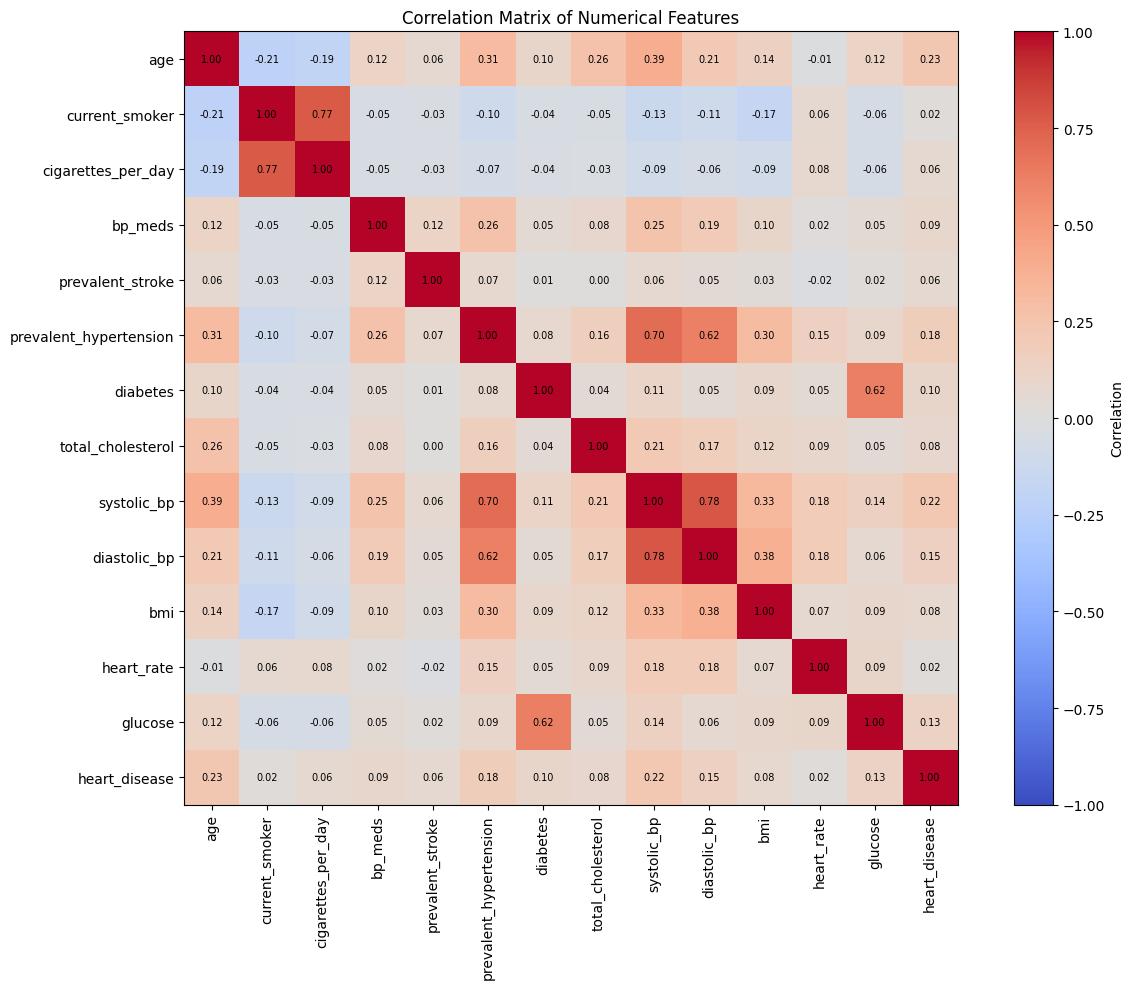

In [8]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

target_correlations = (
    correlation_matrix["heart_disease"]
    .drop("heart_disease")
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False
    )
    .rename("Correlation")
    .reset_index()
    .rename(columns={"index": "Feature"})
)

print("Feature correlations with heart disease:")
display(target_correlations)

fig, ax = plt.subplots(figsize=(13, 10))

heatmap = ax.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.index)))

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=90
)

ax.set_yticklabels(correlation_matrix.index)

for row in range(len(correlation_matrix.index)):
    for column in range(len(correlation_matrix.columns)):
        value = correlation_matrix.iloc[row, column]

        ax.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

ax.set_title("Correlation Matrix of Numerical Features")

fig.colorbar(
    heatmap,
    ax=ax,
    label="Correlation"
)

plt.tight_layout()
plt.show()

In [9]:
outlier_results = []

for column in continuous_columns:
    values = df[column].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    outlier_mask = (
        (values < lower_bound)
        | (values > upper_bound)
    )

    outlier_count = int(outlier_mask.sum())
    outlier_percentage = (
        outlier_count / len(values) * 100
    )

    outlier_results.append({
        "Feature": column,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": outlier_count,
        "Outlier Percentage": round(outlier_percentage, 2)
    })

outlier_summary = pd.DataFrame(outlier_results)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,age,42.00,56.00,14.00,21.00,77.00,0,0.00
1,cigarettes_per_day,0.00,20.00,20.00,-30.00,50.00,12,0.29
2,total_cholesterol,206.00,263.00,57.00,120.50,348.50,56,1.34
3,systolic_bp,117.00,144.00,27.00,76.50,184.50,126,2.97
4,diastolic_bp,75.00,89.88,14.88,52.69,112.19,81,1.91
5,bmi,23.07,28.04,4.97,15.62,35.49,97,2.30
6,heart_rate,68.00,83.00,15.00,45.50,105.50,76,1.79
7,glucose,71.00,87.00,16.00,47.00,111.00,188,4.88
